# HRank (Only) Keyword Extraction
Pure HRank implementation with URL/HTML feature-based keyword scoring and Herald dataset evaluation.

In [1]:
import re
import gzip
import zlib
import urllib.request
from urllib.parse import urlparse
from collections import Counter

from bs4 import BeautifulSoup, Comment
from bs4 import XMLParsedAsHTMLWarning
import warnings
import nltk
from nltk.corpus import stopwords, wordnet
from nltk import wordpunct_tokenize, pos_tag
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)
# Use SnowballStemmer for Finnish
from nltk.stem import SnowballStemmer
# Use Finnish lemmatizer from spacy
import spacy
from compound_split.doc_split import get_best_split

try:
    nlp_fi = spacy.load("fi_core_news_sm")
except:
    import os
    os.system("python3 -m spacy download fi_core_news_sm")
    nlp_fi = spacy.load("fi_core_news_sm")

# --- CONFIGURATION & NLTK SETUP ---
for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

# Noise words to filter out during cleaning
COMMON_NOISE_WORDS = set(
    """
january debt est dec big than who use jun jan feb mar apr may jul agust dec oct nov sep dec
product continue one two three four five please thanks find helpful week job experience women girl
apology read show eve knowledge benefit appointment street way staff salon discount gift cost thing
world close party love letters rewards offers special close page week dollars voucher gifts vouchers
welcome therefore march nights need name pleasure show sisters thank menu today always time needs
welcome march february april may june jully aguast september october november december day year
month minute second secodns
""".split()
    )

SPECIAL_CHARS_RE = re.compile(
    r"[ \~\!\@\#\\\$\%\^\&\*\(\)\_\+\=\\\|\{\}\[\]\:\;\'\"\<\>\,\/\.\-]"
    )

# --- STEM & LEMMATIZATION ---
stemmer = SnowballStemmer("finnish")
# Finnish lemmatization function using spacy
def finnish_lemmatize(word):
    doc = nlp_fi(word)
    return doc[0].lemma_ if doc else word

# Map NLTK POS tags to WordNet POS
POS_MAP = {
    "J": wordnet.ADJ,
    "V": wordnet.VERB,
    "N": wordnet.NOUN,
    "R": wordnet.ADV,
}

def _split_compound_word(word: str) -> list:
    try:
        split_result = get_best_split(word)
        if isinstance(split_result, list):
            return [p.lower() for p in split_result if isinstance(p, str) and p]
        if (
            isinstance(split_result, tuple)
            and len(split_result) == 2
            and isinstance(split_result[1], (list, tuple))
        ):
            return [p.lower() for p in split_result[1] if isinstance(p, str) and p]
    except Exception:
        pass
    return []

def _expand_compound_tokens(tokens: list) -> list:
    expanded = []
    for token in tokens:
        if not token:
            continue
        expanded.append(token)
        for part in _split_compound_word(token):
            if part != token:
                expanded.append(part)
    return expanded

def normalize_keywords(keywords):
    cleaned = [SPECIAL_CHARS_RE.sub("", w.lower().strip()) for w in keywords if w]
    expanded = _expand_compound_tokens(cleaned)
    return _stem_and_lemmatize_tokens(expanded)

def _is_visible_text(element) -> bool:
    if element.parent.name in ["html", "style", "script", "head", "[document]", "img"]:
        return False
    if isinstance(element, Comment):
        return False
    return True

def _extract_visible_text_from_html(html: bytes) -> str:
    soup = BeautifulSoup(html, "lxml")
    texts = soup.find_all(string=True)
    visible_texts = filter(_is_visible_text, texts)
    return " ".join(t.strip() for t in visible_texts if t and t.strip())

def _normalize_whitespace(text: str) -> str:
    lines = (line.strip() for line in text.splitlines())
    chunks = (phrase.strip() for line in lines for phrase in line.split(" "))
    return "\n".join(chunk for chunk in chunks if chunk)

def _decode_response_body(html: bytes, encoding: str) -> bytes:
    enc = (encoding or "").lower()
    if enc == "gzip":
        try:
            return gzip.decompress(html)
        except Exception:
            return html
    if enc == "deflate":
        try:
            return zlib.decompress(html)
        except Exception:
            try:
                return zlib.decompress(html, -zlib.MAX_WBITS)
            except Exception:
                return html
    return html

def _fetch_page(u: str):
    req = urllib.request.Request(
        u,
        headers={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,text/plain;q=0.9,*/*;q=0.8",
            "Accept-Language": "fi-FI,fi;q=0.9",
            "Connection": "keep-alive",
        },
    )
    with urllib.request.urlopen(req, timeout=20) as resp:
        html = resp.read()
        html = _decode_response_body(html, resp.headers.get("Content-Encoding", ""))
        soup = BeautifulSoup(html, "lxml")
        raw_text = _extract_visible_text_from_html(html)
        clean_text = _normalize_whitespace(raw_text)
        return clean_text, soup

def _calculate_language_scores(text: str) -> dict:
    ratios = {}
    tokens = wordpunct_tokenize(text)
    words = [w.lower() for w in tokens]
    words_set = set(words)
    for lang in stopwords.fileids():
        try:
            stop_set = set(stopwords.words(lang))
            common = words_set.intersection(stop_set)
            ratios[lang] = len(common)
        except Exception:
            continue
    return ratios

def _detect_language_and_stopwords(text: str):
    ratios = _calculate_language_scores(text)
    preferred = [
        "finnish", "swedish", "danish", "norwegian", "english",
        "german", "dutch", "french", "spanish", "italian", "portuguese"
    ]
    available = [lang for lang in preferred if lang in stopwords.fileids()]
    if not available:
        return "finnish", set(stopwords.words("finnish"))
    detected = max(available, key=lambda lang: ratios.get(lang, 0))
    try:
        return detected, set(stopwords.words(detected))
    except Exception:
        return "finnish", set(stopwords.words("finnish"))

def _stem_and_lemmatize_tokens(tokens):
    # For Finnish, use spacy lemmatizer and Snowball stemmer
    out = []
    for word in tokens:
        lemma = finnish_lemmatize(word)
        stem = stemmer.stem(lemma)
        out.append(stem)
    return out

def _clean_text_to_words(text: str, stopword_list: set) -> list:
    tokens = [
        SPECIAL_CHARS_RE.sub("", w.lower().strip())
        for w in wordpunct_tokenize(text)
    ]
    tokens = [t for t in tokens if t and len(t) > 1 and not t.isdigit() and t not in stopword_list and t not in COMMON_NOISE_WORDS]
    tokens = _expand_compound_tokens(tokens)
    tokens = _stem_and_lemmatize_tokens(tokens)
    return tokens

# --- URL & TAG ANALYSIS ---
def _split_url_host(u: str) -> list:
    parsed = urlparse(u)
    host = parsed.hostname or ""
    parts = []
    for chunk in host.split("."):
        chunk = chunk.lower()
        if chunk not in ["", "https", "www", "com", "php", "pk", "fi", "http"]:
            parts.append(chunk)
    return parts

def _split_url_path_and_query(u: str, host_parts: list) -> list:
    path_tokens = []
    for segment in u.split("/"):
        for dot_part in segment.split("."):
            for dash_part in dot_part.split("-"):
                token = dash_part.lower()
                if (
                    token
                    and token not in ["https", "www", "com", "php", "pk", "fi", "http"]
                    and token not in host_parts
                ):
                    path_tokens.append(token)
    return path_tokens

def _extract_tag_texts(soup, tag_name: str) -> list:
    return [
        el.get_text(strip=True).lower()
        for el in soup.find_all(tag_name)
        if el.get_text(strip=True)
    ]
def _explode_texts_to_words(text_list: list) -> list:
    out = []
    for text in text_list:
        for comma_chunk in text.split(","):
            for w in comma_chunk.split():
                out.append(w)
    return out

def _extract_headers_anchors_title_words(soup):
    h1 = _explode_texts_to_words(_extract_tag_texts(soup, "h1"))
    h2 = _explode_texts_to_words(_extract_tag_texts(soup, "h2"))
    h3 = _explode_texts_to_words(_extract_tag_texts(soup, "h3"))
    h4 = _explode_texts_to_words(_extract_tag_texts(soup, "h4"))
    h5 = _explode_texts_to_words(_extract_tag_texts(soup, "h5"))
    h6 = _explode_texts_to_words(_extract_tag_texts(soup, "h6"))
    anchor = _explode_texts_to_words(_extract_tag_texts(soup, "a"))
    title = _explode_texts_to_words(_extract_tag_texts(soup, "title"))
    # Apply normalization to tag tokens
    tag_tokens = h1 + h2 + h3 + h4 + h5 + h6 + anchor + title
    tag_tokens = [SPECIAL_CHARS_RE.sub("", t.lower().strip()) for t in tag_tokens if t]
    tag_tokens = _expand_compound_tokens(tag_tokens)
    tag_tokens = _stem_and_lemmatize_tokens(tag_tokens)
    # Split back to lists
    n = 0
    h1n = tag_tokens[n:n+len(h1)]; n += len(h1)
    h2n = tag_tokens[n:n+len(h2)]; n += len(h2)
    h3n = tag_tokens[n:n+len(h3)]; n += len(h3)
    h4n = tag_tokens[n:n+len(h4)]; n += len(h4)
    h5n = tag_tokens[n:n+len(h5)]; n += len(h5)
    h6n = tag_tokens[n:n+len(h6)]; n += len(h6)
    anchorn = tag_tokens[n:n+len(anchor)]; n += len(anchor)
    titlen = tag_tokens[n:n+len(title)]
    return h1n, h2n, h3n, h4n, h5n, h6n, anchorn, titlen

def _tf_score(freq: int, total_tokens: int) -> float:
    if total_tokens < 50:
        return (freq / 100.0) * 50
    return (freq / 100.0) * 20

def _compute_keyword_scores(words: list, soup, u: str) -> dict:
    freq = Counter(words)
    total_tokens = len(words)
    h1, h2, h3, h4, h5, h6, anchor, title = _extract_headers_anchors_title_words(soup)
    url_host = _split_url_host(u)
    url_path = _split_url_path_and_query(u, url_host)
    # Normalize URL tokens
    url_host = [SPECIAL_CHARS_RE.sub("", t.lower().strip()) for t in url_host if t]
    url_host = _expand_compound_tokens(url_host)
    url_host = _stem_and_lemmatize_tokens(url_host)
    url_path = [SPECIAL_CHARS_RE.sub("", t.lower().strip()) for t in url_path if t]
    url_path = _expand_compound_tokens(url_path)
    url_path = _stem_and_lemmatize_tokens(url_path)
    headers_names = ["H1", "H2", "H3", "H4", "H5", "H6", "A", "Title", "URL-H", "URL-Q"]
    headers_scores = [6, 5, 4, 3, 2, 1, 2, 5, 5, 4]
    headers_lists = [h1, h2, h3, h4, h5, h6, anchor, title, url_host, url_path]
    word_info = {}
    for w, c in freq.items():
        base = _tf_score(c, total_tokens)
        tag_boost, tag_names = 0.0, []
        for idx, toks in enumerate(headers_lists):
            if w in toks:
                tag_boost += headers_scores[idx]
                tag_names.append(headers_names[idx])
        word_info[w] = (c, tag_names, base + tag_boost)
    return word_info

def get_top_keywords(url: str, k: int = 10, return_details: bool = False):
    # print(f"Processing URL: {url}")
    clean_text, soup = _fetch_page(url)
    _, stopword_list = _detect_language_and_stopwords(clean_text)
    tokens = _clean_text_to_words(clean_text, stopword_list)
    if not tokens:
        return []
    keyword_data = _compute_keyword_scores(tokens, soup, url)
    top = sorted(keyword_data.items(), key=lambda kv: kv[1][2], reverse=True)[:k]
    if return_details:
        return [(w, meta[0], meta[2], meta[1]) for w, meta in top]
    return [w for w, _ in top]

def Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(ground_truth, keywords):
    gt_set = set(ground_truth)
    kw_set = set(keywords)
    matches = gt_set.intersection(kw_set)
    gt_count, kw_count, match_count = len(gt_set), len(kw_set), len(matches)
    if gt_count == 0 or kw_count == 0:
        return (0, 0, 0)
    precision = match_count / kw_count
    recall = match_count / gt_count
    f_score = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0
    )
    return (precision, recall, f_score)

def read_url(url):
    with urllib.request.urlopen(url) as f:
        return f.read().decode("utf-8-sig", errors="ignore").strip()

def load_herald_case(index):
    BASE = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
    base_url = f"{BASE}/{index}/"
    url_text = read_url(f"{base_url}/URL.txt")
    gt_text = read_url(f"{base_url}/GT.txt")
    return url_text, gt_text.split(), BASE

def run_single_case(index=0, k=10):
    URL, gt_keywords, BASE = load_herald_case(str(index))
    gt_keywords_norm = normalize_keywords(gt_keywords)
    dataset_url = f"{BASE}/{index}"
    found_keywords = get_top_keywords(dataset_url, k=k)
    p, r, f = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(gt_keywords_norm, found_keywords)
    return {
        "index": index,
        "url": URL,
        "ground_truth": gt_keywords,
        "ground_truth_normalized": gt_keywords_norm,
        "predicted": found_keywords,
        "precision": round(p, 4),
        "recall": round(r, 4),
        "f_score": round(f, 4),
    }
def run_evaluation(total_webpages=10):
    p_sum, r_sum, f_sum = 0.0, 0.0, 0.0
    for i in range(total_webpages):
        URL, gt_keywords, BASE = load_herald_case(str(i))
        gt_keywords_norm = normalize_keywords(gt_keywords)
        dataset_url = f"{BASE}/{i}"
        found_keywords = get_top_keywords(dataset_url, k=10)
        p, r, f = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(gt_keywords_norm, found_keywords)
        p_sum, r_sum, f_sum = p_sum + p, r_sum + r, f_sum + f
    avg_p = round(p_sum / total_webpages, 2)
    avg_r = round(r_sum / total_webpages, 2)
    avg_f = round(f_sum / total_webpages, 2)
    return {
        "average_precision": avg_p,
        "average_recall": avg_r,
        "average_f_score": avg_f,
        "total_webpages": total_webpages,
    }
def main(total_webpages=100):
    return run_evaluation(total_webpages=total_webpages)
print("HRank code with Finnish stemming and lemmatization loaded.")

HRank code with Finnish stemming and lemmatization loaded.


In [2]:
# Example: load URL details from Herald dataset and extract keywords
case = run_single_case(index=0, k=10)

print('URL:', case['url'])
print('GT:', case['ground_truth'])
print('GT Normalized:', case['ground_truth_normalized'])
print('Predicted:', case['predicted'])
print('Precision:', case['precision'])
print('Recall:', case['recall'])
print('F-score:', case['f_score'])

URL: http://ruoka.fi/blogit/mukana-maku/afrikan-lampoa-kana-paprika-tagine
GT: ['tagine', 'afrika', 'paprika', 'marokko', 'tajine', 'kana', 'pataruoat', 'kikherneet', 'berber', 'mukana', 'maku']
GT Normalized: ['tag', 'afrik', 'paprik', 'maroko', 'taj', 'ka', 'pataruoa', 'kikherd', 'berber', 'ber', 'muka', 'muk', 'a', 'maku']
Predicted: ['komment', 'ka', 'kom', 'tit', 'afrik', 'paprik', 'tag', 'keskustelu', 'toimitus', 'lämpö']
Precision: 0.4
Recall: 0.2857
F-score: 0.3333


In [3]:
# Run full HRank evaluation
main(total_webpages=10)

{'average_precision': 0.21,
 'average_recall': 0.23,
 'average_f_score': 0.22,
 'total_webpages': 10}

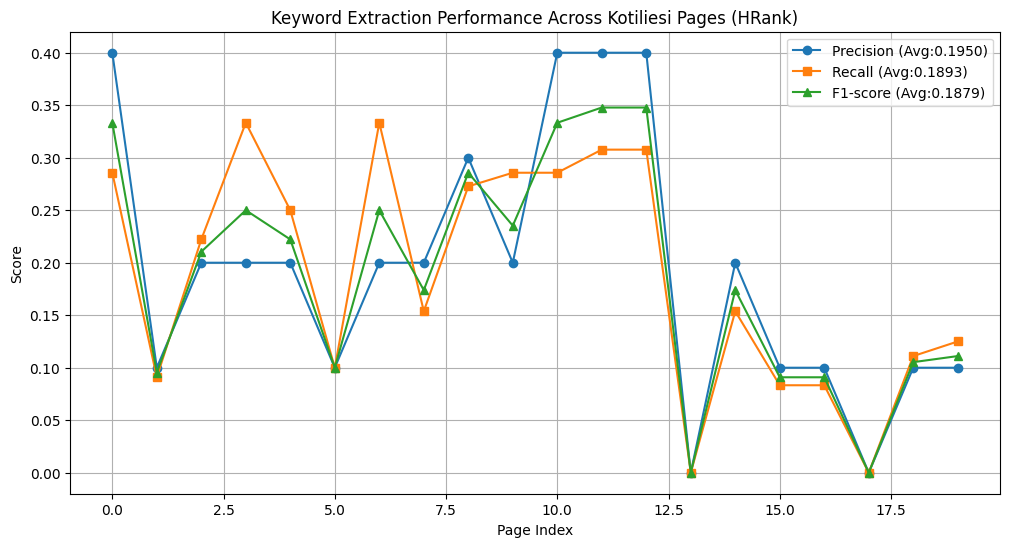

In [4]:
# Visualize and compare performance for HRank (Kotiliesi)
import matplotlib.pyplot as plt
import os
import pandas as pd

results = []
for i in range(20):
    case = run_single_case(index=i, k=10)
    results.append(case)
dataset_precisions = [r['precision'] for r in results]
dataset_recalls = [r['recall'] for r in results]
dataset_f1s = [r['f_score'] for r in results]

plt.figure(figsize=(12, 6))
plt.plot(dataset_precisions, label='Precision (Avg:{0:.4f})'.format(sum(dataset_precisions)/len(dataset_precisions)), marker='o')
plt.plot(dataset_recalls, label='Recall (Avg:{0:.4f})'.format(sum(dataset_recalls)/len(dataset_recalls)), marker='s')
plt.plot(dataset_f1s, label='F1-score (Avg:{0:.4f})'.format(sum(dataset_f1s)/len(dataset_f1s)), marker='^')
plt.xlabel('Page Index')
plt.ylabel('Score')
plt.title('Keyword Extraction Performance Across Kotiliesi Pages (HRank)')
plt.legend()
plt.grid(True)

# Export graph as image
results_dir = '../Results'
os.makedirs(results_dir, exist_ok=True)
image_path = os.path.join(results_dir, 'HRank_Kotiliesi.png')
plt.savefig(image_path)
plt.show()

# Update results.csv
csv_path = os.path.join(results_dir, 'results.csv')
method = 'HRank_Kotiliesi'
avg_precision = round(sum(dataset_precisions)/len(dataset_precisions), 4)
avg_recall = round(sum(dataset_recalls)/len(dataset_recalls), 4)
avg_f1 = round(sum(dataset_f1s)/len(dataset_f1s), 4)

row = {'DataSet': method, 'Precision': avg_precision, 'Recall': avg_recall, 'F1-score': avg_f1, 'Evaluated Pages': len(results)}

if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
    df = pd.read_csv(csv_path)
    df = df[df['DataSet'] != method]
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
else:
    df = pd.DataFrame([row])
df.to_csv(csv_path, index=False)